# Assignment No: 05

#### Rollno. - 33157 DIV-A (TE-CS)

**Source:** https://www.kaggle.com/datasets/spscientist/students-performance-in-exams


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load Dataset
df = pd.read_csv('StudentsPerformance.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (1000, 8)
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [4]:
# Check Missing Values
print("Missing Values:")
print(df.isnull().sum())
print("\nDescribe:")
print(df.describe())

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Describe:
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


In [5]:
# Create Target Variable: Pass(1) or Fail(0) based on math score >= 50
df['reading score'].fillna(df['reading score'].median(), inplace=True)
df['writing score'].fillna(df['writing score'].median(), inplace=True)
df['result'] = (df['math score'] >= 50).astype(int)
print("Target Variable Distribution:")
print(df['result'].value_counts())

Target Variable Distribution:
result
1    865
0    135
Name: count, dtype: int64


In [6]:
# Encode Categorical Variables
le = LabelEncoder()
df['gender_enc']  = le.fit_transform(df['gender'])
df['lunch_enc']   = le.fit_transform(df['lunch'])
df['prep_enc']    = le.fit_transform(df['test preparation course'])
print("Encoding done.")
print(df[['gender','gender_enc','lunch','lunch_enc']].head())

Encoding done.
   gender  gender_enc         lunch  lunch_enc
0  female           0      standard          1
1  female           0      standard          1
2  female           0      standard          1
3    male           1  free/reduced          0
4    male           1      standard          1


In [7]:
# Feature Selection and Train-Test Split
X = df[['gender_enc','lunch_enc','prep_enc','reading score','writing score']]
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (750, 5), Test: (250, 5)


In [8]:
# StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("Scaling done!")

Scaling done!


In [9]:
# Train Logistic Regression Model
model = LogisticRegression(random_state=42)
model.fit(X_train_sc, y_train)
print("Model trained!")
print("Coefficients:", model.coef_)
print("Intercept   :", model.intercept_)

Model trained!
Coefficients: [[1.74328914 0.75175729 0.07801213 1.23775537 2.79745345]]
Intercept   : [5.17329265]


In [10]:
# Predictions
y_pred = model.predict(X_test_sc)

# Sample output
result_df = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10]})
print(result_df)

   Actual  Predicted
0       1          1
1       1          1
2       1          1
3       1          1
4       1          1
5       1          1
6       1          1
7       1          1
8       1          1
9       1          1


=== Confusion Matrix ===
  TP=199  FP=17
  FN=8  TN=26


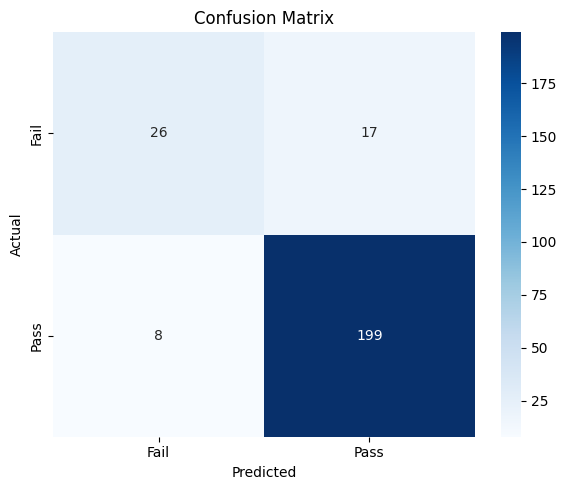

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
print("=== Confusion Matrix ===")
print(f"  TP={TP}  FP={FP}")
print(f"  FN={FN}  TN={TN}")

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail','Pass'], yticklabels=['Fail','Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [12]:
# Performance Metrics
print("=== Performance Metrics ===")
print(f"Accuracy   : {accuracy_score(y_test, y_pred):.4f}")
print(f"Error Rate : {1 - accuracy_score(y_test, y_pred):.4f}")
print(f"Precision  : {precision_score(y_test, y_pred):.4f}")
print(f"Recall     : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score   : {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fail','Pass']))

=== Performance Metrics ===
Accuracy   : 0.9000
Error Rate : 0.1000
Precision  : 0.9213
Recall     : 0.9614
F1-Score   : 0.9409

Classification Report:
              precision    recall  f1-score   support

        Fail       0.76      0.60      0.68        43
        Pass       0.92      0.96      0.94       207

    accuracy                           0.90       250
   macro avg       0.84      0.78      0.81       250
weighted avg       0.89      0.90      0.90       250

